# 01 · Politicians × YouTube

Built on `polarization.py`. Writes `user_counts.csv`, `channel_df.csv`, `video_df.csv`.

In [1]:
import sys
sys.path.append(".")          # polarization.py sits next to this notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import polarization as P

In [2]:
from pathlib import Path

ROOT = Path("dataset")

In [3]:
PLATFORM      = "YouTube"
PRODUCER_TYPE = "Politician"

OUT = ROOT/"politicians"/"youtube"

In [4]:
path = ROOT / "politicians" / "youtube" / "scraped_comments.json"

print(path)
print(path.resolve())
print(path.exists())

dataset\politicians\youtube\scraped_comments.json
D:\School\2026 Spring\KR_Polarization\dataset\politicians\youtube\scraped_comments.json
True


## 1. Load comments

In [5]:
df = P.flatten_youtube_comments(
    ROOT / "politicians" / "youtube" / "scraped_comments.json"
)

print(df.shape)
df.head()

  996,901 rows -> 314 MB in memory
(996901, 11)


,video_id,video_title,channel_id,channel_name,channel_url,comment_id,parent_id,type,author,like_count,timestamp
0,P2uRVr_hR6Y,강경숙이 간다! #서울 #은평구 #구의원 # 김진회 #후보 #지방선거 #강경숙 #조...,UCOwFB9e0aPnkSyCDvkNytDg,강경숙TV,https://www.youtube.com/@%EA%B0%95%EA%B2%BD%EC...,Ugwppudfy5sX_juIyz94AaABAg,None,comment,@김영옥-r8e,0,2026-04-27T11:08:14Z
1,5cmPT-ZXOsE,"고유가 장기화 대비, &#39;경제 체질 개선&#39; 이 정답 #강경숙 #조국혁신...",UCOwFB9e0aPnkSyCDvkNytDg,강경숙TV,https://www.youtube.com/@%EA%B0%95%EA%B2%BD%EC...,UgwxLIo28BkExAwUcfh4AaABAg,None,comment,@dbxbqj-hf2ug,0,2026-04-22T12:32:26Z
2,z5mk_Xl5Ht0,군위는 왜 강대식인가?,UCBjEdkZDj17XalrKDmKhyaw,강대식tv,https://www.youtube.com/@tv-li4jl,UgwyuNlYAlduOJocmeZ4AaABAg,None,comment,@kaileen-ht5ny,0,2025-01-19T08:20:56Z
3,z5mk_Xl5Ht0,군위는 왜 강대식인가?,UCBjEdkZDj17XalrKDmKhyaw,강대식tv,https://www.youtube.com/@tv-li4jl,Ugzecy3lrah2LENIVTN4AaABAg,None,comment,@이-12345,0,2024-12-24T21:48:05Z
4,z5mk_Xl5Ht0,군위는 왜 강대식인가?,UCBjEdkZDj17XalrKDmKhyaw,강대식tv,https://www.youtube.com/@tv-li4jl,UgwDEmDuv20ZjEcQmJ54AaABAg,None,comment,@goldsosilver,0,2024-12-18T03:27:39Z


In [4]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    utc=True,
    errors="coerce"
)

print("Earliest:", df["timestamp"].min())
print("Latest:", df["timestamp"].max())

Earliest: 2012-10-10 10:16:28+00:00
Latest: 2026-05-04 16:10:03+00:00


In [4]:
summary = pd.DataFrame({
    "Total": [
        df["channel_id"].nunique(),
        df["video_id"].nunique(),
        df["comment_id"].nunique(),
        df["author"].nunique()
    ]
}, index=[
    "Channels",
    "Videos",
    "Comments",
    "Users"
])

summary

,Total
Channels,277
Videos,41032
Comments,996901
Users,350880


In [5]:
df["type"].value_counts()

type
comment    926531
reply       70370
Name: count, dtype: int64

## 2. Ideology lookup

In [6]:
ideo = P.politician_ideology(
    ROOT / "22ndKRHouseRepMembers.xlsx",
    PLATFORM
)

ideo.head()

  ideology map (YouTube): 282 producers -> {'left': 176, 'right': 100, 'independent': 6}


,key,producer_name,ideology
0,https://www.youtube.com/@%EA%B0%95%EA%B2%BD%EC...,강경숙,left
1,https://www.youtube.com/@tv-li4jl,강대식,right
2,https://www.youtube.com/@kang_deukgu,강득구,left
3,https://www.youtube.com/@0909kmg,강명구,right
4,https://www.youtube.com/@strongwind01,강민국,right


In [ ]:
ideo["ideology"].value_counts()


ideology
left           176
right          100
independent      6
Name: count, dtype: int64

## 3. Prepare

Dedupe on `comment_id`, attach ideology, drop producer self-comments, fold
`independent` into left. Read the printout: a low match rate means the lookup
keys don't line up, and a big drop at the dedupe step means the source file
holds each record more than once.

In [6]:
prepared = P.prepare(df, ideo, PLATFORM)

  dedupe on comment_id: 996,901 -> 996,901
  ideology matched: 996,901 / 996,901 (100.0%)
  self-comments dropped: 0
  independent -> left: 59,430


## 4. User-level measures

In [12]:
uc_5, _ = P.user_measures(prepared, min_comments=5)
uc_10, _ = P.user_measures(prepared, min_comments=10)
uc_20, _ = P.user_measures(prepared, min_comments=20)

  authors: 350,880 | active (>=5): 41,471 | comments kept: 527,992
  users on >1 producer: 26,734 / 41,471 (64.5%)
  authors: 350,880 | active (>=10): 15,376 | comments kept: 361,500
  users on >1 producer: 10,998 / 15,376 (71.5%)
  authors: 350,880 | active (>=20): 5,282 | comments kept: 228,601
  users on >1 producer: 3,994 / 5,282 (75.6%)


In [13]:
for threshold, uc in [
    (5, uc_5),
    (10, uc_10),
    (20, uc_20)
]:
    # Add labels
    uc["producer_type"] = PRODUCER_TYPE
    uc["platform"] = PLATFORM

    # Verify labels
    pt = set(uc["producer_type"])
    pl = set(uc["platform"])

    assert pt == {PRODUCER_TYPE}
    assert pl == {PLATFORM}

    # Save
    uc.to_csv(
        f"{OUT}/user_counts_{threshold}.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print(
        f"user_counts_{threshold}: "
        f"{len(uc):,} users | {pt} | {pl} | saved"
    )

user_counts_5: 41,471 users | {'Politician'} | {'YouTube'} | saved
user_counts_10: 15,376 users | {'Politician'} | {'YouTube'} | saved
user_counts_20: 5,282 users | {'Politician'} | {'YouTube'} | saved


In [7]:
user_counts, comment_users = P.user_measures(prepared, min_comments=P.MIN_COMMENTS)

user_counts = P.tag(user_counts, PLATFORM, PRODUCER_TYPE)
user_counts.head()

  authors: 350,880 | active (>=20): 5,282 | comments kept: 228,601
  users on >1 producer: 3,994 / 5,282 (75.6%)


,author,left,right,user_bias,user_cross_cut,total,n_producers,activity_band,platform,producer_type
0,@-me1yz243,60,0,-1.000000,0.000000,60,5,50–99,YouTube,Politician
1,@0-young423,27,0,-1.000000,0.000000,27,11,20–49,YouTube,Politician
2,@00-xf2e,0,44,1.000000,0.000000,44,1,20–49,YouTube,Politician
3,@000님,72,0,-1.000000,0.000000,72,6,50–99,YouTube,Politician
4,@0109jean,31,5,-0.722222,0.478395,36,13,20–49,YouTube,Politician


In [8]:
youtube_summary = {
    "Producers/Channels": comment_users["channel_id"].nunique(),
    "YouTube videos": comment_users["video_id"].nunique(),
    "YouTube comments": comment_users["comment_id"].nunique(),
}

youtube_summary

{'Producers/Channels': 259,
 'YouTube videos': 29997,
 'YouTube comments': 228601}

In [11]:
user_counts[["user_bias", "user_cross_cut", "total", "n_producers"]].describe()

,user_bias,user_cross_cut,total,n_producers
count,5282.000000,5282.000000,5282.000000,5282.000000
mean,-0.324715,0.073879,43.279250,5.594850
std,0.906000,0.197982,68.216794,5.571742
min,-1.000000,0.000000,20.000000,0.000000
25%,-1.000000,0.000000,23.000000,2.000000
50%,-1.000000,0.000000,30.000000,4.000000
75%,1.000000,0.000000,44.000000,8.000000
max,1.000000,1.000000,2840.000000,90.000000


In [9]:
bias_neg1_pct = (user_counts["user_bias"] == -1).mean() * 100
bias_pos1_pct = (user_counts["user_bias"] == 1).mean() * 100

print(f"Bias = -1: {bias_neg1_pct:.2f}%")
print(f"Bias = +1: {bias_pos1_pct:.2f}%")

Bias = -1: 53.65%
Bias = +1: 25.60%


In [11]:
zero_pct = (user_counts["user_cross_cut"] == 0).mean() * 100
positive_pct = (user_counts["user_cross_cut"] > 0).mean() * 100

print(f"Cross-cut = 0: {zero_pct:.2f}%")
print(f"Cross-cut > 0: {positive_pct:.2f}%")

Cross-cut = 0: 79.25%
Cross-cut > 0: 20.75%


### Producers per user

`user_bias` only varies for users who comment across more than one producer.
If this share is low the measure collapses to +/-1 and cross-cutting goes to 0
by construction rather than by finding.

In [12]:
multi = (user_counts["n_producers"] > 1).sum()

print(f"users on >1 producer: {multi:,} / {len(user_counts):,} "
      f"({multi / len(user_counts):.1%})")

user_counts["n_producers"].describe()

users on >1 producer: 3,994 / 5,282 (75.6%)


count    5282.000000
mean        5.594850
std         5.571742
min         0.000000
25%         2.000000
50%         4.000000
75%         8.000000
max        90.000000
Name: n_producers, dtype: float64

## 5. Distributions

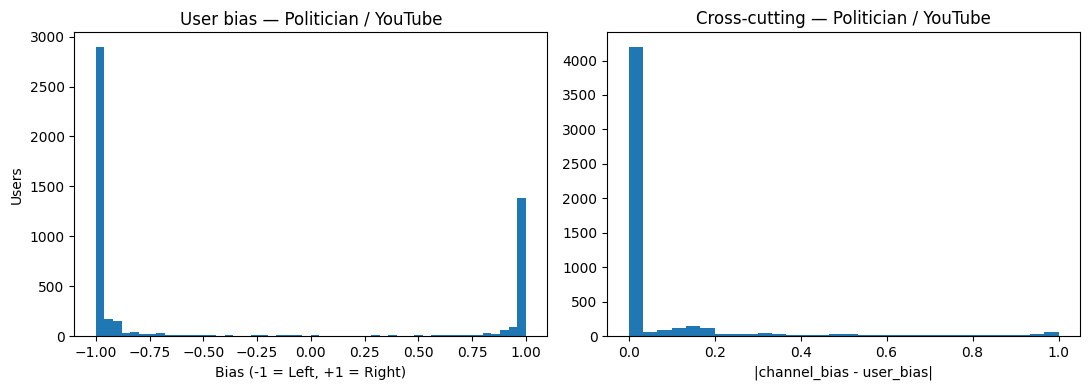

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(user_counts["user_bias"], bins=50)
ax[0].set_title(f"User bias — {PRODUCER_TYPE} / {PLATFORM}")
ax[0].set_xlabel("Bias (-1 = Left, +1 = Right)")
ax[0].set_ylabel("Users")

ax[1].hist(user_counts["user_cross_cut"].dropna(), bins=30)
ax[1].set_title(f"Cross-cutting — {PRODUCER_TYPE} / {PLATFORM}")
ax[1].set_xlabel("|channel_bias - user_bias|")

plt.tight_layout()
plt.show()

### Audience size

`producer_stats.csv` comes from `fetch_audience_size.py` — YouTube subscriber
counts via the Data API, Instagram follower counts via instaloader. If the file
isn't there yet the notebook still runs; `audience_size` is just NaN and the
control drops out of the regressions.

In [14]:
import os

_stats_path = f"{OUT}/producer_stats.csv"

if os.path.exists(_stats_path):
    stats = P.load_producer_stats(_stats_path)
else:
    stats = None
    print("no producer_stats.csv yet -- audience_size will be NaN")

  producer stats: 282 / 282 with a usable count


## 6. Producer- and item-level aggregates

In [15]:
channel_df = P.channel_level(comment_users, PLATFORM, PRODUCER_TYPE, stats)
video_df   = P.video_level(comment_users, PLATFORM, PRODUCER_TYPE, stats)

print("producers:", channel_df.shape)
print("items    :", video_df.shape)

channel_df.head()

producers: (259, 14)
items    : (29997, 16)


,key,channel_id,channel_name,producer_name,ideology,channel_url,mean_user_bias,mean_cross_cutting,n_comments,n_users,total_likes,audience_size,platform,producer_type
0,https://www.youtube.com/@%EA%B0%95%EA%B2%BD%EC...,UCOwFB9e0aPnkSyCDvkNytDg,강경숙TV,강경숙,left,https://www.youtube.com/@%EA%B0%95%EA%B2%BD%EC...,-1.000000,0.000000,17,7,10,3550,YouTube,Politician
1,https://www.youtube.com/@%EA%B0%95%EB%82%A8%EA...,UC1k7xYX5MvynCeSUvlkK_Vg,서명옥 강남갑 국회의원,서명옥,right,https://www.youtube.com/@%EA%B0%95%EB%82%A8%EA...,0.475312,0.524688,56,24,135,905,YouTube,Politician
2,https://www.youtube.com/@%EA%B0%95%EC%84%A0%EC...,UCTDli6TqWf2P-mWuJpFby3w,강선우,강선우,left,https://www.youtube.com/@%EA%B0%95%EC%84%A0%EC...,-0.970330,0.029670,27,17,112,91800,YouTube,Politician
3,https://www.youtube.com/@%EA%B3%BD%EC%83%81%EC...,UCHmBMimjBdm4AwWkuCAML_Q,곽상언TV,곽상언,left,https://www.youtube.com/@%EA%B3%BD%EC%83%81%EC...,-1.000000,0.000000,4,4,16,48000,YouTube,Politician
4,https://www.youtube.com/@%EA%B5%AD%ED%9A%8C%EC...,UCrIWiDrst31FGTGe5fy8-RA,안호영의 안테나,안호영,left,https://www.youtube.com/@%EA%B5%AD%ED%9A%8C%EC...,-0.974933,0.025067,1558,278,7279,12600,YouTube,Politician


### Label check

All three outputs must carry the same `producer_type` / `platform`. The
previous notebooks wrote `"YouTuber"` into the politician files and
`"Politician"` into the youtuber user counts, which silently flattened the
group comparison in the regressions.

In [16]:
for name, frame in [("user_counts", user_counts),
                    ("channel_df", channel_df),
                    ("video_df", video_df)]:
    pt, pl = set(frame["producer_type"]), set(frame["platform"])
    ok = pt == {PRODUCER_TYPE} and pl == {PLATFORM}
    print(f"{name:12} {pt} {pl} {'OK' if ok else '<<< MISLABELLED'}")
    assert ok, name

user_counts  {'Politician'} {'YouTube'} OK
channel_df   {'Politician'} {'YouTube'} OK
video_df     {'Politician'} {'YouTube'} OK


## 7. Save

In [17]:
user_counts.to_csv(f"{OUT}/user_counts.csv", index=False, encoding="utf-8-sig")
channel_df.to_csv(f"{OUT}/channel_df.csv", index=False, encoding="utf-8-sig")
video_df.to_csv(f"{OUT}/video_df.csv", index=False, encoding="utf-8-sig")

print("saved to", OUT)

saved to D:/School/2026 Spring/KR_Polarization/dataset/politicians/youtube
